# Autoencoder for EEG Feature Extraction

このnotebookでは、ICAとエポック分割済みの脳波データに対してAutoencoder (AE)を適用し、特徴量抽出を行います。

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns

In [2]:
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## データの読み込み

In [3]:
# エポック別に保存されたウェーブレット変換済みデータの読み込み
import os
from pathlib import Path
from tqdm import tqdm

# ウェーブレット特徴量ディレクトリ
wavelet_dir = Path("../../data/bcidatasetIV2a/processed/wavelet_features_25hz")

# エポックファイルの数を確認
epoch_files = sorted(list(wavelet_dir.glob("epoch_*.pkl")))
n_epochs = len(epoch_files)
print(f"Found {n_epochs} epoch files")

# 最初のエポックを読み込んでデータ構造を確認
with open(epoch_files[0], 'rb') as f:
    sample_epoch = pickle.load(f)

print(f"Sample epoch data type: {type(sample_epoch)}")
if isinstance(sample_epoch, dict):
    print("Sample epoch data keys:", sample_epoch.keys())
    for key, value in sample_epoch.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {type(value)} - shape {value.shape}")
        else:
            print(f"  {key}: {type(value)}")
else:
    print(f"Sample epoch data shape: {sample_epoch.shape}")

# ラベルデータを別途読み込み（元のエポックデータから）
original_data_path = "../../data/bcidatasetIV2a/processed/merged.pkl"
with open(original_data_path, 'rb') as f:
    original_data = pickle.load(f)
labels = original_data['labels']

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

Found 228 epoch files
Sample epoch data type: <class 'numpy.ndarray'>
Sample epoch data shape: (22, 2, 63, 75)
Labels shape: (2592,)
Unique labels: [769 770 771 772]


## データ前処理

In [4]:
# エポック別ウェーブレットデータを順次読み込み、メモリ効率的に処理
def load_wavelet_data_incrementally(epoch_files, batch_size=100):
    """
    エポック別ウェーブレットデータを小バッチずつ読み込み
    """
    all_data = []
    metadata = None
    
    print(f"Loading {len(epoch_files)} epochs in batches of {batch_size}...")
    
    for i in tqdm(range(0, len(epoch_files), batch_size), desc="Loading batches"):
        batch_files = epoch_files[i:i+batch_size]
        batch_data = []
        
        for epoch_file in batch_files:
            with open(epoch_file, 'rb') as f:
                epoch_data = pickle.load(f)
                
                if isinstance(epoch_data, dict):
                    # 辞書形式の場合、ウェーブレット係数を取得
                    if 'coefficients' in epoch_data:
                        wavelet_coeffs = epoch_data['coefficients']
                    elif 'wavelet_coeffs' in epoch_data:
                        wavelet_coeffs = epoch_data['wavelet_coeffs']
                    else:
                        # 最初のarray要素を取得
                        wavelet_coeffs = list(epoch_data.values())[0]
                    
                    # メタデータを保存（最初のエポックから）
                    if metadata is None:
                        metadata = {k: v for k, v in epoch_data.items() if k != 'coefficients' and k != 'wavelet_coeffs'}
                else:
                    # 直接arrayの場合
                    wavelet_coeffs = epoch_data
                
                batch_data.append(wavelet_coeffs)
        
        # バッチを結合
        if batch_data:
            batch_array = np.stack(batch_data, axis=0)
            all_data.append(batch_array)
            print(f"Batch {i//batch_size + 1}: loaded {len(batch_data)} epochs, shape: {batch_array.shape}")
    
    # すべてのバッチを結合
    if all_data:
        final_data = np.concatenate(all_data, axis=0)
        print(f"Final concatenated shape: {final_data.shape}")
        return final_data, metadata
    else:
        return None, None

# ウェーブレットデータを読み込み
wavelet_coeffs, wavelet_metadata = load_wavelet_data_incrementally(epoch_files[:min(1600, len(epoch_files))])  # 最初の1600エポックを使用

if wavelet_coeffs is not None:
    print(f"Loaded wavelet coefficients shape: {wavelet_coeffs.shape}")
    
    # ラベルをエポック数に合わせて調整
    y = labels[:wavelet_coeffs.shape[0]]
    print(f"Adjusted labels shape: {y.shape}")
    
    # データ形状情報を取得
    if len(wavelet_coeffs.shape) == 5:
        n_epochs, n_channels, n_windows, n_scales, n_times = wavelet_coeffs.shape
    elif len(wavelet_coeffs.shape) == 4:
        n_epochs, n_channels, n_scales, n_times = wavelet_coeffs.shape
        n_windows = 1
        wavelet_coeffs = wavelet_coeffs[:, :, np.newaxis, :, :]  # windowsの次元を追加
    else:
        raise ValueError(f"Unexpected data shape: {wavelet_coeffs.shape}")
    
    print(f"Data dimensions: epochs={n_epochs}, channels={n_channels}, windows={n_windows}, scales={n_scales}, times={n_times}")
    
    # 2D畳み込み用のデータ形状に変換
    # (n_epochs, n_channels * n_windows, n_scales, n_times)の形に変換
    X_2d = wavelet_coeffs.reshape(n_epochs, n_channels * n_windows, n_scales, n_times)
    
    print(f"2D convolution data shape: {X_2d.shape}")
    print(f"Input channels for CNN: {n_channels * n_windows}")
    print(f"Spatial dimensions: {n_scales} x {n_times}")
    
    # データの標準化（チャンネルごと）
    scaler = StandardScaler()
    # (n_epochs, n_channels, n_scales*n_times)に reshape してから標準化
    X_flat_for_scaling = X_2d.reshape(n_epochs, n_channels * n_windows, -1)
    X_normalized_flat = np.zeros_like(X_flat_for_scaling)
    
    for ch in range(n_channels * n_windows):
        X_normalized_flat[:, ch, :] = scaler.fit_transform(X_flat_for_scaling[:, ch, :].T).T
    
    # 元の2D形状に戻す
    X_normalized = X_normalized_flat.reshape(n_epochs, n_channels * n_windows, n_scales, n_times)
    
    print(f"正規化後のデータ範囲: 最小値={X_normalized.min()}, 最大値={X_normalized.max()}")
    
    # 訓練・検証・テストセットに分割
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_normalized, y, test_size=0.2, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = X_temp, X_temp, y_temp, y_temp  # 検証セットはテストセットと同じにする
    
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    print(f"Test set shape: {X_test.shape}")
    
    # データ形状の情報を保存（後で再構成時に使用）
    data_shape_info = {
        'n_epochs': n_epochs,
        'n_channels': n_channels, 
        'n_windows': n_windows,
        'n_scales': n_scales,
        'n_times': n_times,
        'input_channels': n_channels * n_windows,
        'spatial_height': n_scales,
        'spatial_width': n_times
    }
    
    print("Data loading and preprocessing completed successfully!")
else:
    print("Failed to load wavelet data")

Loading 228 epochs in batches of 100...


Loading batches:  33%|███▎      | 1/3 [00:03<00:06,  3.32s/it]

Batch 1: loaded 100 epochs, shape: (100, 22, 2, 63, 75)


Loading batches:  67%|██████▋   | 2/3 [00:04<00:02,  2.02s/it]

Batch 2: loaded 100 epochs, shape: (100, 22, 2, 63, 75)


Loading batches: 100%|██████████| 3/3 [00:04<00:00,  1.56s/it]

Batch 3: loaded 28 epochs, shape: (28, 22, 2, 63, 75)


Final concatenated shape: (228, 22, 2, 63, 75)
Loaded wavelet coefficients shape: (228, 22, 2, 63, 75)
Adjusted labels shape: (228,)
Data dimensions: epochs=228, channels=22, windows=2, scales=63, times=75
2D convolution data shape: (228, 44, 63, 75)
Input channels for CNN: 44
Spatial dimensions: 63 x 75
正規化後のデータ範囲: 最小値=-1.9727043932224868, 最大値=6.832970723462912
Training set shape: (182, 44, 63, 75)
Validation set shape: (46, 44, 63, 75)
Test set shape: (46, 44, 63, 75)
Data loading and preprocessing completed successfully!


## Autoencoder モデル定義

In [7]:
class WaveletConv2DAutoencoder(nn.Module):
    def __init__(self, input_channels, spatial_height, spatial_width, latent_dim=64):
        super(WaveletConv2DAutoencoder, self).__init__()
        
        self.input_channels = input_channels
        self.spatial_height = spatial_height
        self.spatial_width = spatial_width
        self.latent_dim = latent_dim
        
        # Encoder - 2D畳み込みでウェーブレット特徴量を圧縮
        self.encoder = nn.Sequential(
            # 第1畳み込みブロック (入力: input_channels x 63 x 75)
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 32 x 31 x 37
            
            # 第2畳み込みブロック
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 64 x 15 x 18
            
            # 第3畳み込みブロック
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 128 x 7 x 9
            
            # 第4畳み込みブロック
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 5))  # -> 256 x 4 x 5 = 5120
        )
        
        # エンコーダの出力サイズを計算
        self.encoder_output_size = 256 * 4 * 5  # 5120
        
        # 潜在空間への変換
        self.fc_encode = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.encoder_output_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, latent_dim)
        )
        
        # 潜在空間からデコーダへの変換
        self.fc_decode = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, self.encoder_output_size)
        )
        
        # Decoder - 転置畳み込みで再構成
        self.decoder = nn.Sequential(
            # 形状を戻す: -> 256 x 4 x 5
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 128 x 8 x 10
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),   # -> 64 x 16 x 20
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),    # -> 32 x 32 x 40
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> input_channels x 64 x 80
            # 最終的な調整レイヤー
            nn.AdaptiveAvgPool2d((spatial_height, spatial_width))  # -> input_channels x 63 x 75
        )    
    def encode(self, x):
        """
        データを潜在表現にエンコード
        """
        conv_out = self.encoder(x)
        latent = self.fc_encode(conv_out)
        return latent
    
    def decode(self, z):
        """
        潜在表現からデータを再構成
        """
        fc_out = self.fc_decode(z)
        # 畳み込み形状に戻す
        conv_input = fc_out.view(-1, 256, 4, 5)
        recon = self.decoder(conv_input)
        return recon
    
    def forward(self, x):
        """
        前方伝播：エンコード→デコード
        """
        z = self.encode(x)
        recon_x = self.decode(z)
        return recon_x, z

def autoencoder_loss(recon_x, x):
    """
    Autoencoder損失関数（再構成誤差のみ）
    """
    # 再構成誤差（MSE）
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    return recon_loss

## モデルの初期化とトレーニング準備

In [8]:
# デバイスの設定（メモリ不足の場合はCPUを使用）
def get_safe_device():
    """GPUメモリをチェックして安全なデバイスを選択"""
    if torch.cuda.is_available():
        try:
            # 簡単なテンソルを作成してGPUメモリをテスト
            test_tensor = torch.randn(100, 100).cuda()
            del test_tensor
            torch.cuda.empty_cache()
            return torch.device('cuda')
        except RuntimeError as e:
            if "out of memory" in str(e):
                print("GPU memory insufficient, switching to CPU")
                return torch.device('cpu')
            else:
                raise e
    else:
        return torch.device('cpu')

device = get_safe_device()
print(f"Using device: {device}")

# ウェーブレット2D畳み込みAutoencoderモデルパラメータ
input_channels = data_shape_info['input_channels']  # n_channels * n_windows
spatial_height = data_shape_info['spatial_height']  # n_scales
spatial_width = data_shape_info['spatial_width']    # n_times
latent_dim = 64    # 潜在次元数
batch_size = 16    # バッチサイズを小さく（2D畳み込みはメモリを多く使用）
learning_rate = 0.001  # 学習率

# モデルの初期化
model = WaveletConv2DAutoencoder(input_channels, spatial_height, spatial_width, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# StepLRスケジューラの追加
step_size = 50  # 50エポックごとに学習率を減衰
gamma = 0.5     # 学習率の減衰率
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input channels: {input_channels}")
print(f"Spatial dimensions: {spatial_height} x {spatial_width}")
print(f"Latent dimension: {latent_dim}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"LR scheduler: StepLR(step_size={step_size}, gamma={gamma})")

# GPUメモリが不足している場合の対処法を表示
if device.type == 'cpu':
    print("\n⚠️  CPU mode: Training will be slower but more memory efficient")
    print("Tips to save memory:")
    print("- Reduce batch_size if needed")
    print("- Consider reducing latent_dim")

Using device: cuda
Model parameters: 6,116,268
Input channels: 44
Spatial dimensions: 63 x 75
Latent dimension: 64
Batch size: 16
Learning rate: 0.001
LR scheduler: StepLR(step_size=50, gamma=0.5)


In [9]:
# データローダーの作成
train_dataset = TensorDataset(torch.FloatTensor(X_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

Train loader: 12 batches
Val loader: 3 batches
Test loader: 3 batches


## モデルのトレーニング

In [10]:
def calculate_accuracy(model, data_loader, device, y_true):
    """Autoencoderの潜在特徴量を使って分類精度を計算"""
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score
    
    model.eval()
    features = []
    
    with torch.no_grad():
        for data, in data_loader:
            data = data.to(device)
            z = model.encode(data)  # 決定論的な潜在特徴量
            features.append(z.cpu().numpy())
    
    features = np.vstack(features)
    
    # 簡単なSVMで分類精度を計算
    try:
        clf = SVC(kernel='rbf', C=1.0, random_state=42)
        clf.fit(features, y_true)
        y_pred = clf.predict(features)
        accuracy = accuracy_score(y_true, y_pred)
        return accuracy
    except:
        return 0.0  # エラー時は0を返す

def train_epoch(model, train_loader, optimizer, device):
    model.train()
    train_loss = 0
    
    for batch_idx, (data,) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, _ = model(data)
        loss = autoencoder_loss(recon_batch, data)
        
        loss.backward()
        # 勾配クリッピング（安定化のため）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    return train_loss / len(train_loader.dataset)

def validate_epoch(model, val_loader, device):
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, in val_loader:
            data = data.to(device)
            recon_batch, _ = model(data)
            loss = autoencoder_loss(recon_batch, data)
            val_loss += loss.item()
    
    return val_loss / len(val_loader.dataset)

In [25]:
# トレーニングループ
num_epochs = 500
train_losses = []
val_losses = []
train_accuracies = []  # 学習データの正答率を記録
val_accuracies = []    # 検証データの正答率を記録
learning_rates = []  # 学習率の履歴を追跡

best_val_loss = float('inf')
patience = 20
patience_counter = 0

print("トレーニング開始...")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = validate_epoch(model, val_loader, device)
    
    # スケジューラのステップを実行
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    learning_rates.append(current_lr)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # 10エポックごとに正答率を計算して表示
    if epoch % 10 == 0:
        train_acc = calculate_accuracy(model, train_loader, device, y_train)
        val_acc = calculate_accuracy(model, val_loader, device, y_val)
        train_accuracies.append((epoch, train_acc))
        val_accuracies.append((epoch, val_acc))
        
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, '
              f'LR: {current_lr:.6f}')
    else:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'LR: {current_lr:.6f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ベストモデルを保存
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': val_loss,
        }, 'best_autoencoder_model.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("トレーニング完了!")

# 最終的な精度計算
final_train_acc = calculate_accuracy(model, train_loader, device, y_train)
final_val_acc = calculate_accuracy(model, val_loader, device, y_val)
final_test_acc = calculate_accuracy(model, test_loader, device, y_test)

print(f"\n最終結果:")
print(f"学習データ精度: {final_train_acc:.4f}")
print(f"検証データ精度: {final_val_acc:.4f}")
print(f"テストデータ精度: {final_test_acc:.4f}")

トレーニング開始...


Epoch   0: Train Loss: 113087.5687, Val Loss: 124599.6413, Train Acc: 0.4341, Val Acc: 0.6304, LR: 0.000125
Epoch   1: Train Loss: 112801.1353, Val Loss: 125045.0462, LR: 0.000125
Epoch   2: Train Loss: 112531.9512, Val Loss: 125216.3940, LR: 0.000125
Epoch   3: Train Loss: 112687.6944, Val Loss: 125436.6957, LR: 0.000125
Epoch   4: Train Loss: 112250.5474, Val Loss: 125779.3995, LR: 0.000125
Epoch   5: Train Loss: 111780.6786, Val Loss: 125744.1522, LR: 0.000125
Epoch   6: Train Loss: 111760.6174, Val Loss: 125619.5109, LR: 0.000125
Epoch   7: Train Loss: 111592.6174, Val Loss: 125725.9375, LR: 0.000125
Epoch   8: Train Loss: 111712.5082, Val Loss: 125747.1033, LR: 0.000125
Epoch   9: Train Loss: 110896.9550, Val Loss: 125709.5842, LR: 0.000125
Epoch  10: Train Loss: 110993.2308, Val Loss: 125994.0000, Train Acc: 0.4505, Val Acc: 0.5870, LR: 0.000125
Epoch  11: Train Loss: 110385.2352, Val Loss: 126152.7201, LR: 0.000125
Epoch  12: Train Loss: 110124.7768, Val Loss: 125976.3234, LR: 0

## トレーニング結果の可視化

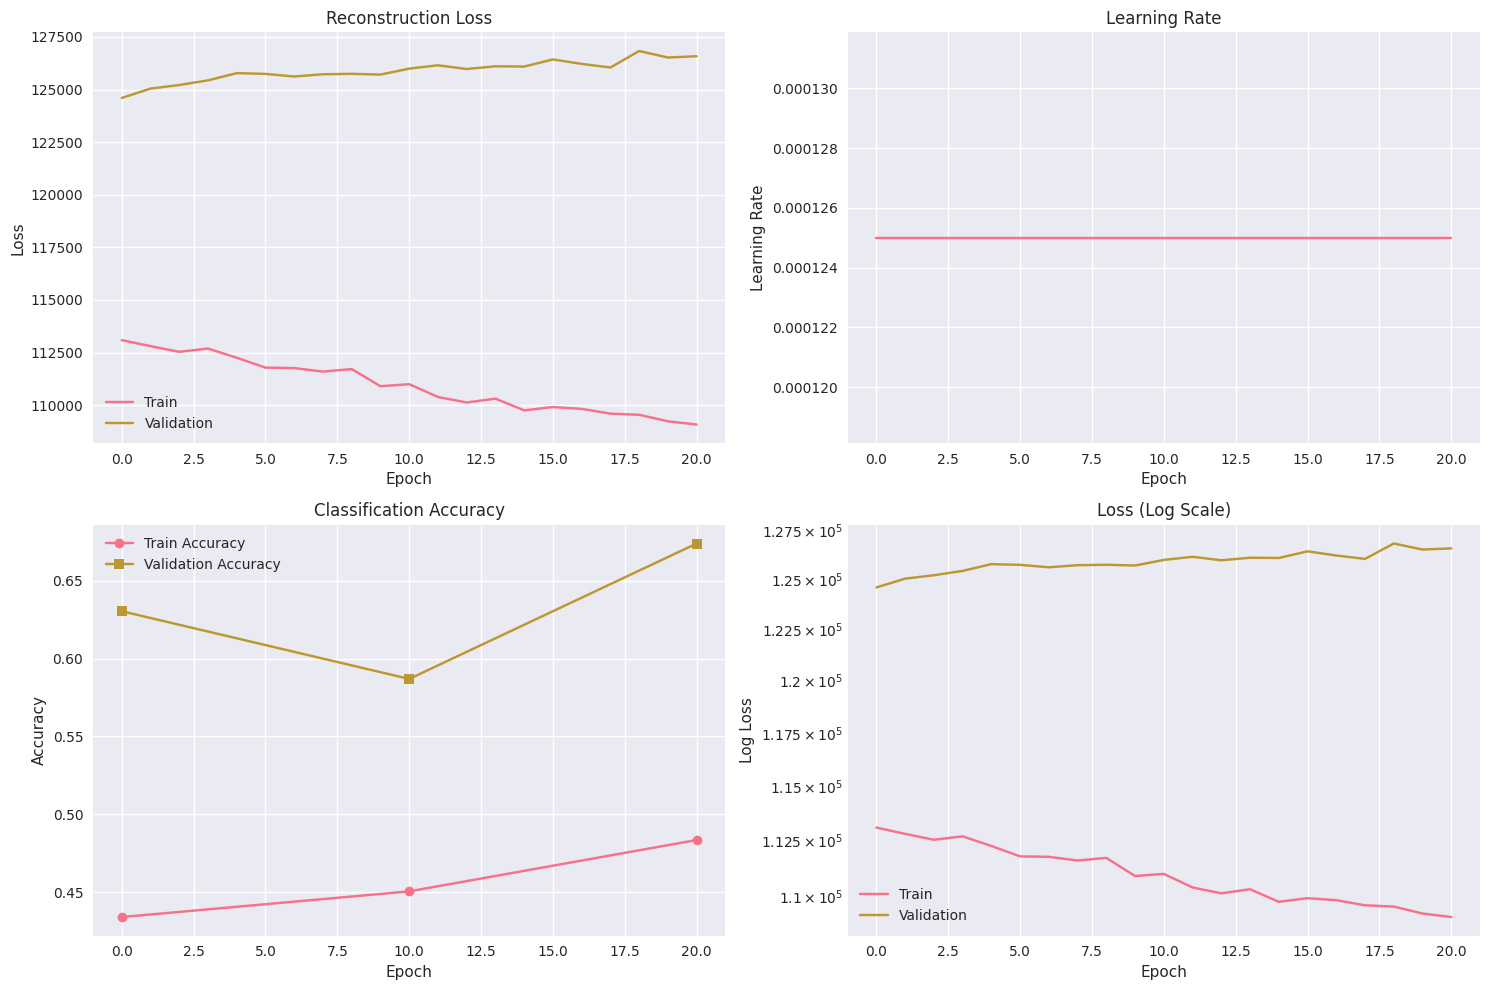

In [26]:
# ベストモデルをロード
if device.type == 'cuda':
    torch.cuda.empty_cache()
checkpoint = torch.load('best_autoencoder_model.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

# 損失の推移をプロット
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 総損失
axes[0, 0].plot(train_losses, label='Train')
axes[0, 0].plot(val_losses, label='Validation')
axes[0, 0].set_title('Reconstruction Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 学習率の推移
axes[0, 1].plot(learning_rates)
axes[0, 1].set_title('Learning Rate')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Learning Rate')
axes[0, 1].grid(True)

# 精度の推移をプロット
if train_accuracies and val_accuracies:
    train_epochs, train_accs = zip(*train_accuracies)
    val_epochs, val_accs = zip(*val_accuracies)
    
    axes[1, 0].plot(train_epochs, train_accs, label='Train Accuracy', marker='o')
    axes[1, 0].plot(val_epochs, val_accs, label='Validation Accuracy', marker='s')
    axes[1, 0].set_title('Classification Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
else:
    axes[1, 0].axis('off')

# 損失の対数スケール
axes[1, 1].semilogy(train_losses, label='Train')
axes[1, 1].semilogy(val_losses, label='Validation')
axes[1, 1].set_title('Loss (Log Scale)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Log Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 特徴量抽出と分析

Extracting latent features...
Latent features shape: (274, 64)
Labels shape: (274,)
Unique labels: [769 770 771 772]
\n=== 交差検証による分類性能評価 ===\n
Training SVM classifier with cross-validation...
SVM交差検証結果:
  CV精度: 0.2879 ± 0.0519
  各Fold: ['0.308', '0.368', '0.289', '0.263', '0.211']
  テスト精度: 0.3253
\nTraining Random Forest classifier with cross-validation...
Random Forest交差検証結果:
  CV精度: 0.3610 ± 0.0515
  各Fold: ['0.410', '0.263', '0.395', '0.368', '0.368']
  テスト精度: 0.4699
\n=== Autoencoder潜在特徴量を使った分類結果 ===\n
SVM詳細レポート:
              precision    recall  f1-score   support

         769       0.33      0.43      0.38        21
         770       0.38      0.41      0.39        22
         771       0.35      0.32      0.33        19
         772       0.20      0.14      0.17        21

    accuracy                           0.33        83
   macro avg       0.32      0.32      0.32        83
weighted avg       0.32      0.33      0.32        83

\nRandom Forest詳細レポート:
              preci

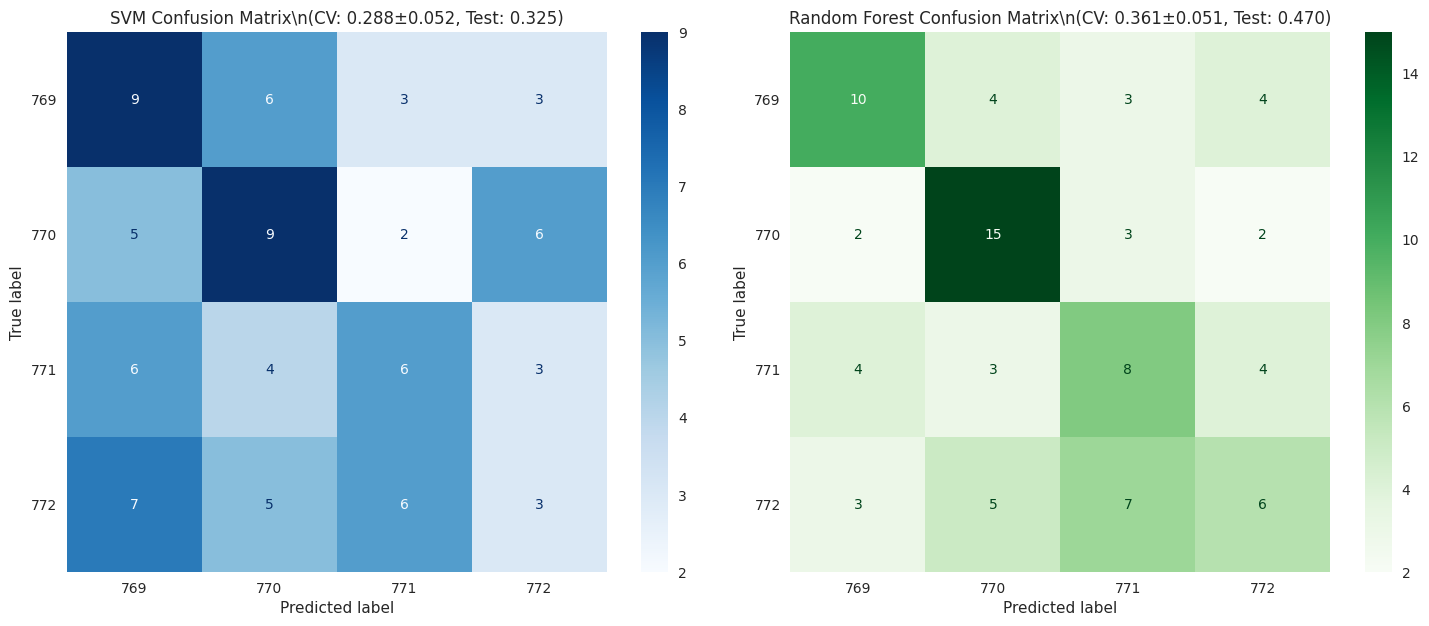

In [27]:
# 全データに対して潜在特徴量を抽出（メモリ効率版）
def extract_features_safely(model, data_loader, device):
    """メモリ効率的に潜在特徴量を抽出"""
    model.eval()
    features = []
    
    with torch.no_grad():
        for data, in data_loader:
            data = data.to(device)
            z = model.encode(data)  # 決定論的な潜在特徴量
            features.append(z.cpu().numpy())
            
            # GPUメモリをクリア
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    return np.vstack(features)

print("Extracting latent features...")

# 各データセットから潜在特徴量を抽出
train_features = extract_features_safely(model, train_loader, device)
val_features = extract_features_safely(model, val_loader, device)
test_features = extract_features_safely(model, test_loader, device)

# 特徴量とラベルを結合
latent_features = np.vstack([train_features, val_features, test_features])
all_labels = np.concatenate([y_train, y_val, y_test])

print(f"Latent features shape: {latent_features.shape}")
print(f"Labels shape: {all_labels.shape}")
print(f"Unique labels: {np.unique(all_labels)}")

# 分類精度の詳細評価（交差検証付き）
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# データを再分割して分類性能を評価
X_latent_train, X_latent_test, y_latent_train, y_latent_test = train_test_split(
    latent_features, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)

print("\\n=== 交差検証による分類性能評価 ===\\n")

# 交差検証の設定
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SVMで交差検証
print("Training SVM classifier with cross-validation...")
svm_classifier = SVC(kernel='rbf', C=1.0, random_state=42)
svm_cv_scores = cross_val_score(svm_classifier, X_latent_train, y_latent_train, cv=cv, scoring='accuracy')
svm_classifier.fit(X_latent_train, y_latent_train)
y_pred_svm = svm_classifier.predict(X_latent_test)

print(f"SVM交差検証結果:")
print(f"  CV精度: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")
print(f"  各Fold: {[f'{score:.3f}' for score in svm_cv_scores]}")
print(f"  テスト精度: {accuracy_score(y_latent_test, y_pred_svm):.4f}")

# Random Forestで交差検証
print("\\nTraining Random Forest classifier with cross-validation...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cv_scores = cross_val_score(rf_classifier, X_latent_train, y_latent_train, cv=cv, scoring='accuracy')
rf_classifier.fit(X_latent_train, y_latent_train)
y_pred_rf = rf_classifier.predict(X_latent_test)

print(f"Random Forest交差検証結果:")
print(f"  CV精度: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"  各Fold: {[f'{score:.3f}' for score in rf_cv_scores]}")
print(f"  テスト精度: {accuracy_score(y_latent_test, y_pred_rf):.4f}")

print(f"\\n=== Autoencoder潜在特徴量を使った分類結果 ===\\n")

print(f"SVM詳細レポート:")
print(classification_report(y_latent_test, y_pred_svm))

print(f"\\nRandom Forest詳細レポート:")
print(classification_report(y_latent_test, y_pred_rf))

# 混同行列を表示
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# SVM混同行列
cm_svm = confusion_matrix(y_latent_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=np.unique(all_labels))
disp_svm.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'SVM Confusion Matrix\\n(CV: {svm_cv_scores.mean():.3f}±{svm_cv_scores.std():.3f}, Test: {accuracy_score(y_latent_test, y_pred_svm):.3f})')
axes[0].grid(False)

# Random Forest混同行列
cm_rf = confusion_matrix(y_latent_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=np.unique(all_labels))
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Random Forest Confusion Matrix\\n(CV: {rf_cv_scores.mean():.3f}±{rf_cv_scores.std():.3f}, Test: {accuracy_score(y_latent_test, y_pred_rf):.3f})')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 潜在特徴量の可視化

Using 274 samples for visualization
Running t-SNE...


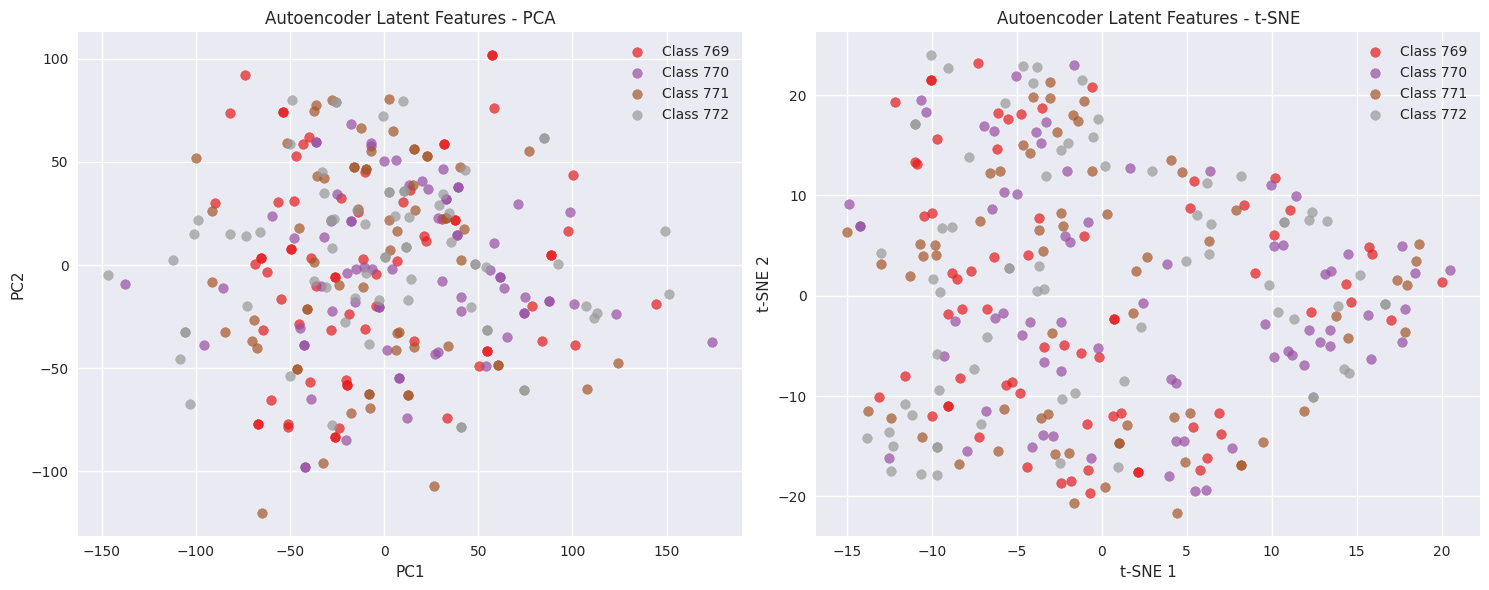

Visualization completed successfully!


In [28]:
# t-SNEによる2次元可視化（メモリ効率版）
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# メモリ節約のため、データをサブサンプル
max_samples = min(1000, len(latent_features))  # 最大1000サンプル
if len(latent_features) > max_samples:
    indices = np.random.choice(len(latent_features), max_samples, replace=False)
    features_subset = latent_features[indices]
    labels_subset = all_labels[indices]
else:
    features_subset = latent_features
    labels_subset = all_labels

print(f"Using {len(features_subset)} samples for visualization")

# PCAで次元削減してからt-SNE（計算時間短縮のため）
pca = PCA(n_components=min(50, features_subset.shape[1]))
features_pca = pca.fit_transform(features_subset)

print("Running t-SNE...")
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(features_subset)//4))
features_tsne = tsne.fit_transform(features_pca)

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCAによる可視化
unique_labels = np.unique(labels_subset)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = labels_subset == label
    axes[0].scatter(features_pca[mask, 0], features_pca[mask, 1], 
                   c=[colors[i]], label=f'Class {label}', alpha=0.7)

axes[0].set_title('Autoencoder Latent Features - PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# t-SNEによる可視化
for i, label in enumerate(unique_labels):
    mask = labels_subset == label
    axes[1].scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                   c=[colors[i]], label=f'Class {label}', alpha=0.7)

axes[1].set_title('Autoencoder Latent Features - t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Visualization completed successfully!")

## 再構成性能の評価

Original shape: (3, 44, 63, 75)
Reconstructed shape: (3, 44, 63, 75)


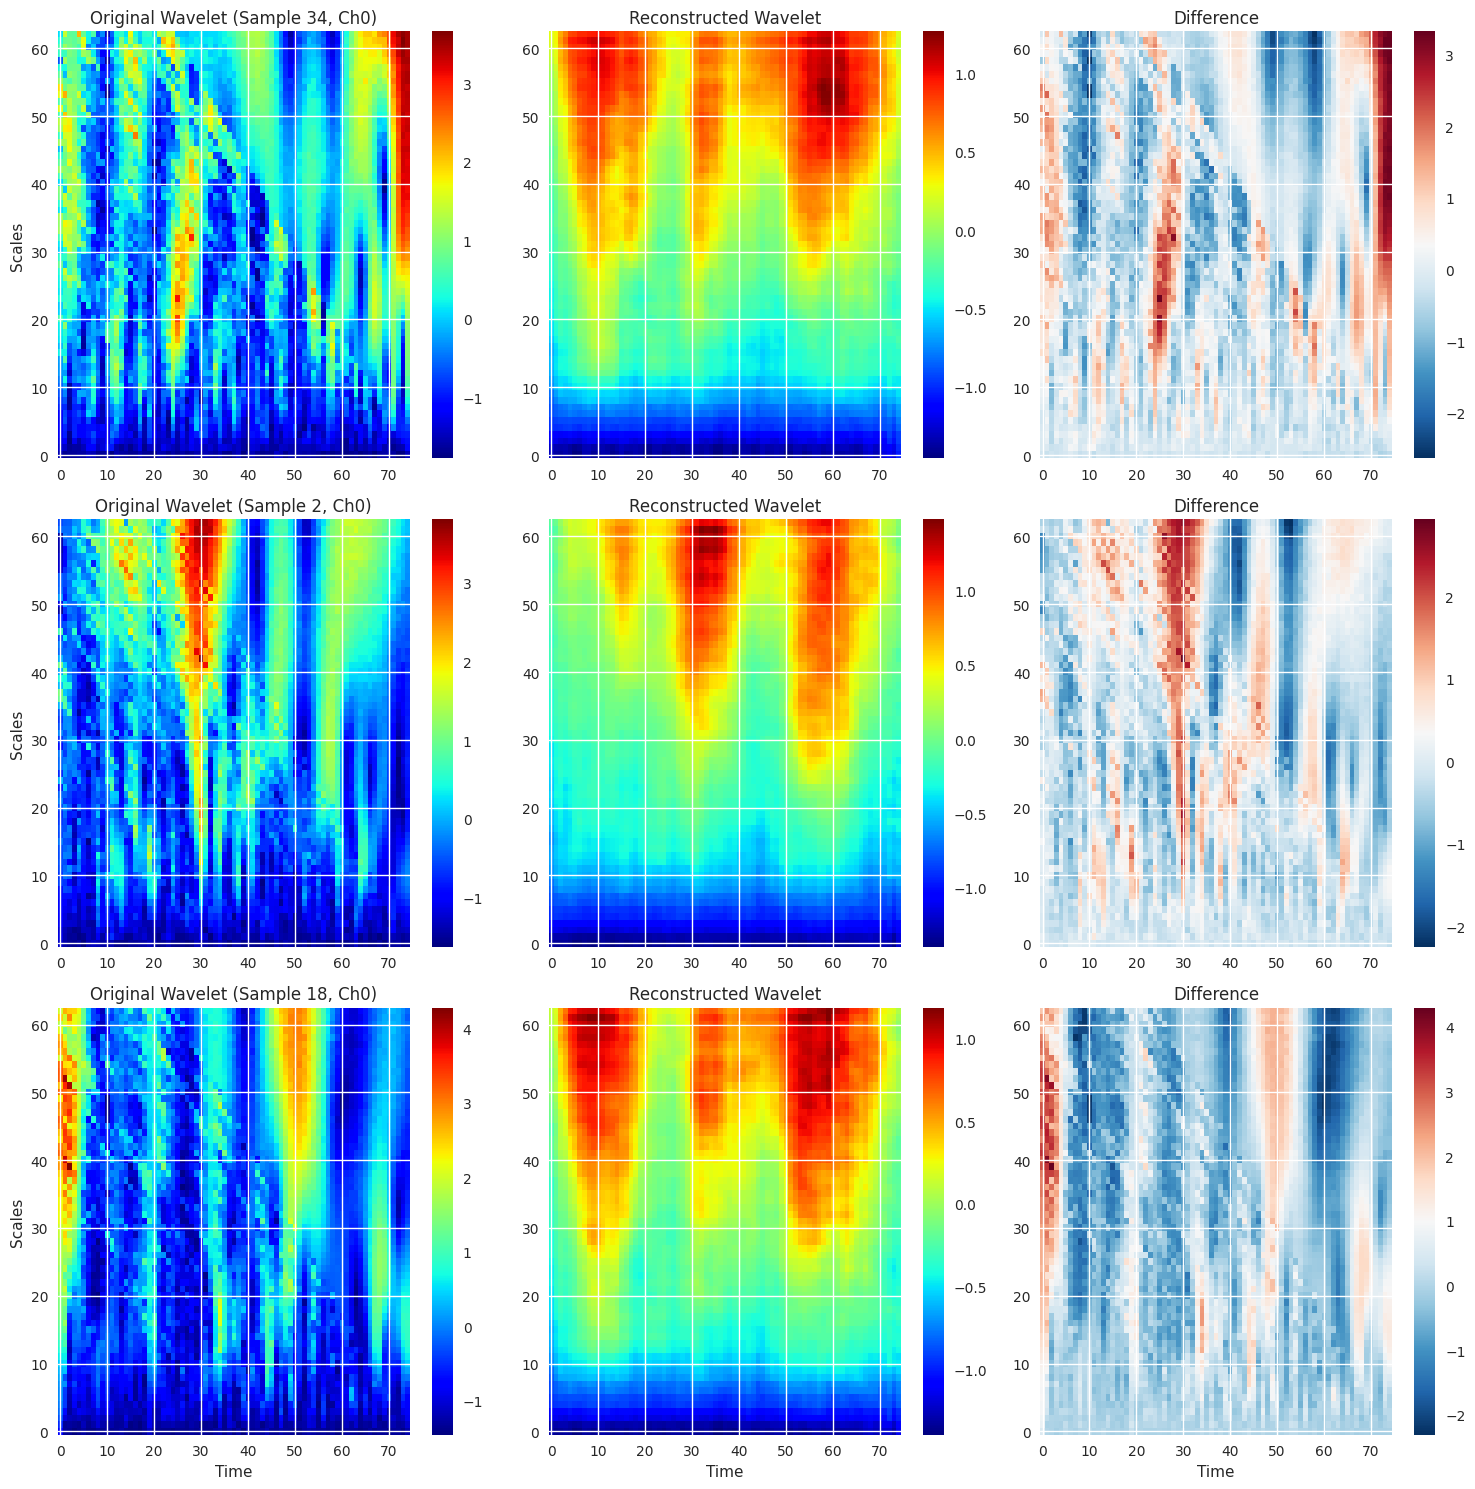

ウェーブレット再構成MSE: 平均=0.608580, 標準偏差=0.066586
潜在変数の統計:
  平均: [ 11.573091 -21.589273  12.225917 -12.044875  12.09608 ]... (最初の5次元)
  標準偏差: [9.592269  3.865263  9.913903  2.9952395 1.6336514]... (最初の5次元)
Reconstruction evaluation completed successfully!


In [29]:
# テストデータでの再構成を可視化（2D畳み込み版）
model.eval()
with torch.no_grad():
    # いくつかのサンプルを選択
    sample_indices = np.random.choice(len(X_test), 3, replace=False)
    samples = torch.FloatTensor(X_test[sample_indices]).to(device)
    
    # 再構成
    recon_samples, z = model(samples)
    
    # CPUに移動
    original = samples.cpu().numpy()
    reconstructed = recon_samples.cpu().numpy()
    latent = z.cpu().numpy()
    
    # GPUメモリをクリア
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print(f"Original shape: {original.shape}")
print(f"Reconstructed shape: {reconstructed.shape}")

# 可視化（最初のチャンネルのウェーブレット係数）
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 5*len(sample_indices)))

for i in range(len(sample_indices)):
    # 最初のチャンネルのウェーブレット係数を表示
    ch_idx = 0
    original_wavelet = original[i, ch_idx]  # (n_scales, n_times)
    reconstructed_wavelet = reconstructed[i, ch_idx]  # (n_scales, n_times)
    
    # オリジナル
    im1 = axes[i, 0].imshow(original_wavelet, aspect='auto', cmap='jet', origin='lower')
    axes[i, 0].set_title(f'Original Wavelet (Sample {sample_indices[i]}, Ch{ch_idx})')
    axes[i, 0].set_ylabel('Scales')
    if i == len(sample_indices) - 1:
        axes[i, 0].set_xlabel('Time')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # 再構成
    im2 = axes[i, 1].imshow(reconstructed_wavelet, aspect='auto', cmap='jet', origin='lower')
    axes[i, 1].set_title('Reconstructed Wavelet')
    if i == len(sample_indices) - 1:
        axes[i, 1].set_xlabel('Time')
    plt.colorbar(im2, ax=axes[i, 1])
    
    # 差分
    diff = original_wavelet - reconstructed_wavelet
    im3 = axes[i, 2].imshow(diff, aspect='auto', cmap='RdBu_r', origin='lower')
    axes[i, 2].set_title('Difference')
    if i == len(sample_indices) - 1:
        axes[i, 2].set_xlabel('Time')
    plt.colorbar(im3, ax=axes[i, 2])

plt.tight_layout()
plt.show()

# 再構成誤差の統計
mse_errors = np.mean((original - reconstructed) ** 2, axis=(1, 2, 3))
print(f"ウェーブレット再構成MSE: 平均={np.mean(mse_errors):.6f}, 標準偏差={np.std(mse_errors):.6f}")

# 潜在変数の統計
print(f"潜在変数の統計:")
print(f"  平均: {np.mean(latent, axis=0)[:5]}... (最初の5次元)")
print(f"  標準偏差: {np.std(latent, axis=0)[:5]}... (最初の5次元)")

print("Reconstruction evaluation completed successfully!")

## 潜在空間の分析

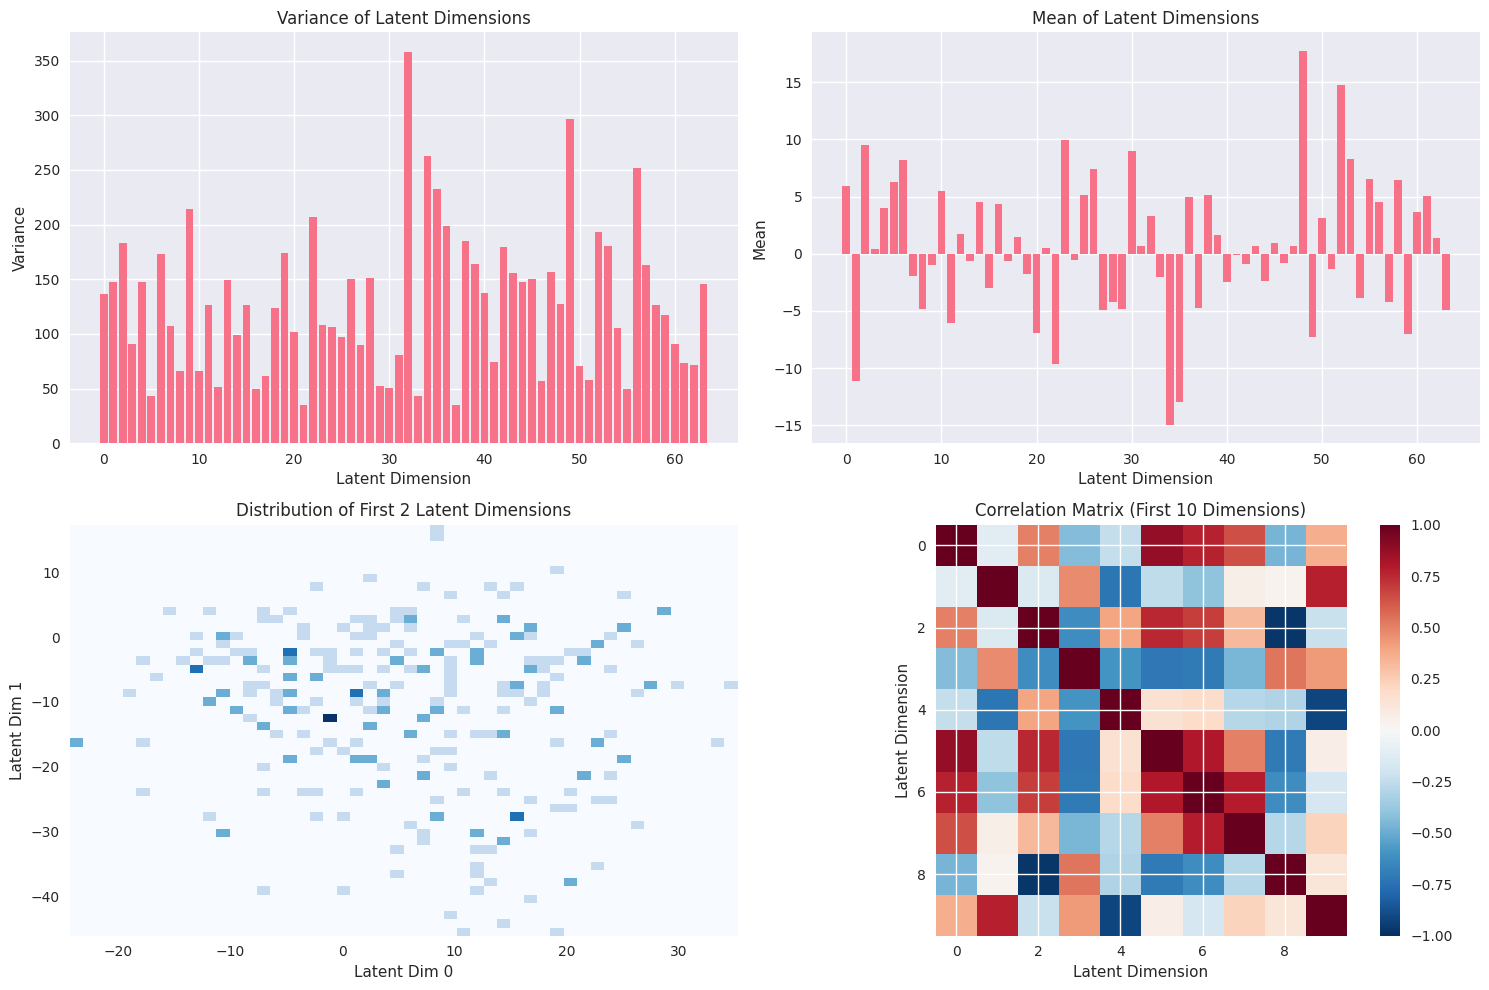

In [30]:
# 潜在次元ごとの分散を可視化
latent_var = np.var(latent_features, axis=0)
latent_mean = np.mean(latent_features, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 潜在次元の分散
axes[0, 0].bar(range(latent_dim), latent_var)
axes[0, 0].set_title('Variance of Latent Dimensions')
axes[0, 0].set_xlabel('Latent Dimension')
axes[0, 0].set_ylabel('Variance')
axes[0, 0].grid(True)

# 潜在次元の平均
axes[0, 1].bar(range(latent_dim), latent_mean)
axes[0, 1].set_title('Mean of Latent Dimensions')
axes[0, 1].set_xlabel('Latent Dimension')
axes[0, 1].set_ylabel('Mean')
axes[0, 1].grid(True)

# 潜在特徴量の分布（最初の2次元）
axes[1, 0].hist2d(latent_features[:, 0], latent_features[:, 1], bins=50, cmap='Blues')
axes[1, 0].set_title('Distribution of First 2 Latent Dimensions')
axes[1, 0].set_xlabel('Latent Dim 0')
axes[1, 0].set_ylabel('Latent Dim 1')

# 相関行列（最初の10次元）
corr_matrix = np.corrcoef(latent_features[:, :10].T)
im = axes[1, 1].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 1].set_title('Correlation Matrix (First 10 Dimensions)')
axes[1, 1].set_xlabel('Latent Dimension')
axes[1, 1].set_ylabel('Latent Dimension')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 混同行列による分類性能の詳細分析

In [31]:
# 元の特徴量での分類結果（比較用）  
print("\\n=== 元の特徴量での分類結果（比較用）===\\n")

# 元の特徴量でSVMを訓練
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X_normalized, y, test_size=0.3, random_state=42, stratify=y
)

# 元の特徴量での交差検証
print("元の特徴量での交差検証結果:")

# SVM
svm_orig = SVC(kernel='rbf', C=1.0, random_state=42)
svm_orig_cv_scores = cross_val_score(svm_orig, X_orig_train, y_orig_train, cv=cv, scoring='accuracy')
svm_orig.fit(X_orig_train, y_orig_train)
y_pred_orig_svm = svm_orig.predict(X_orig_test)

print(f"\\n元の特徴量 + SVM:")
print(f"  CV精度: {svm_orig_cv_scores.mean():.4f} ± {svm_orig_cv_scores.std():.4f}")
print(f"  各Fold: {[f'{score:.3f}' for score in svm_orig_cv_scores]}")
print(f"  テスト精度: {accuracy_score(y_orig_test, y_pred_orig_svm):.4f}")

# Random Forest  
rf_orig = RandomForestClassifier(n_estimators=100, random_state=42)
rf_orig_cv_scores = cross_val_score(rf_orig, X_orig_train, y_orig_train, cv=cv, scoring='accuracy')
rf_orig.fit(X_orig_train, y_orig_train)
y_pred_orig_rf = rf_orig.predict(X_orig_test)

print(f"\\n元の特徴量 + Random Forest:")
print(f"  CV精度: {rf_orig_cv_scores.mean():.4f} ± {rf_orig_cv_scores.std():.4f}")
print(f"  各Fold: {[f'{score:.3f}' for score in rf_orig_cv_scores]}")
print(f"  テスト精度: {accuracy_score(y_orig_test, y_pred_orig_rf):.4f}")

# 元の特徴量の混同行列を表示
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 元の特徴量 + SVM混同行列
cm_orig_svm = confusion_matrix(y_orig_test, y_pred_orig_svm)
disp_orig_svm = ConfusionMatrixDisplay(confusion_matrix=cm_orig_svm, display_labels=np.unique(all_labels))
disp_orig_svm.plot(ax=axes[0], cmap='Oranges', values_format='d')
axes[0].set_title(f'Original Features + SVM\\n(CV: {svm_orig_cv_scores.mean():.3f}±{svm_orig_cv_scores.std():.3f}, Test: {accuracy_score(y_orig_test, y_pred_orig_svm):.3f})')
axes[0].grid(False)

# 元の特徴量 + Random Forest混同行列
cm_orig_rf = confusion_matrix(y_orig_test, y_pred_orig_rf)
disp_orig_rf = ConfusionMatrixDisplay(confusion_matrix=cm_orig_rf, display_labels=np.unique(all_labels))
disp_orig_rf.plot(ax=axes[1], cmap='Purples', values_format='d')
axes[1].set_title(f'Original Features + Random Forest\\n(CV: {rf_orig_cv_scores.mean():.3f}±{rf_orig_cv_scores.std():.3f}, Test: {accuracy_score(y_orig_test, y_pred_orig_rf):.3f})')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print(f"\\n=== 比較結果のサマリー ===")
print(f"Autoencoder + SVM: CV {svm_cv_scores.mean():.3f}±{svm_cv_scores.std():.3f}, Test {accuracy_score(y_latent_test, y_pred_svm):.3f}")
print(f"Autoencoder + RF:  CV {rf_cv_scores.mean():.3f}±{rf_cv_scores.std():.3f}, Test {accuracy_score(y_latent_test, y_pred_rf):.3f}")
print(f"Original + SVM:    CV {svm_orig_cv_scores.mean():.3f}±{svm_orig_cv_scores.std():.3f}, Test {accuracy_score(y_orig_test, y_pred_orig_svm):.3f}")
print(f"Original + RF:     CV {rf_orig_cv_scores.mean():.3f}±{rf_orig_cv_scores.std():.3f}, Test {accuracy_score(y_orig_test, y_pred_orig_rf):.3f}")

\n=== 元の特徴量での分類結果（比較用）===\n
元の特徴量での交差検証結果:


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py", line 197, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site

## 特徴量の保存

In [ ]:
# ウェーブレット2D畳み込みAutoencoder特徴量と関連情報を保存
wavelet_conv_ae_results = {
    'latent_features': latent_features,
    'labels': all_labels,
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'train_indices': list(range(len(y_train))),
    'val_indices': list(range(len(y_train), len(y_train) + len(y_val))),
    'test_indices': list(range(len(y_train) + len(y_val), len(all_labels))),
    'model_params': {
        'input_channels': input_channels,
        'spatial_height': spatial_height,
        'spatial_width': spatial_width,
        'latent_dim': latent_dim,
    },
    'data_shape_info': data_shape_info,  # データ形状情報
    'wavelet_metadata': wavelet_metadata,  # ウェーブレット変換のメタデータ
    'training_history': {
        'train_losses': train_losses,
        'val_losses': val_losses
    }
}

# 保存
output_path = "wavelet_conv2d_autoencoder_features.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(wavelet_conv_ae_results, f)

print(f"ウェーブレット2D畳み込みAutoencoder特徴量を {output_path} に保存しました")
print(f"潜在特徴量の形状: {latent_features.shape}")
print(f"潜在次元数: {latent_dim}")
print(f"入力データ形状: {input_channels} x {spatial_height} x {spatial_width}")
print(f"元の5次元データ形状: {data_shape_info}")
print(f"使用したエポック数: {data_shape_info['n_epochs']}")

# メタデータ情報を表示
if wavelet_metadata:
    print("ウェーブレットメタデータ:")
    for key, value in wavelet_metadata.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {type(value)} - shape {value.shape}")
        else:
            print(f"  {key}: {type(value)} - {value}")
            
print("\\n2D畳み込みAutoencoder特徴量の抽出が完了しました！")